In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
import sklearn.preprocessing as sp
import matplotlib.pyplot as plt
import os
from scipy.signal import savgol_filter
from scipy.stats import ttest_ind

In [2]:
def find_end_slope2(data, height=None, subject=None,smooth=False):

    if smooth:
        data = savgol_filter(data, window_length=5, polyorder=3)
    
    min_max_indc=[np.argmax(data), np.argmin(data)]
    last_peak_ind0=[i for i in min_max_indc if (i<len(data)-2)]# and (i>0)]
    if last_peak_ind0==[]:
        return 0
    
    last_peak_ind=np.max(last_peak_ind0)

    slope = (data[-1] - data[last_peak_ind]) / (len(data) - last_peak_ind-1)
    return last_peak_ind, slope

def round_sig(x, sig=2):
#     To round to n significant digits (non-zero digits)
    if x == 0:
        return 0
    return round(x, sig - int(np.floor(np.log10(abs(x)))) - 1)

In [3]:
ag_df = pd.read_csv('aggregated_profiles_fibroblast.csv')
controls = ag_df.loc[ag_df['label'] == 'Control']['subject'].to_list()
bipolar = ag_df.loc[ag_df['label'] == 'BP']['subject'].to_list()
population = ag_df['subject'].to_list()
# drop 370 because it was split into 370A-370H
population = [x for x in population if x != '370']

In [4]:
# sql_data available from https://doi.org/10.5281/zenodo.15390513
# downloaded locally for this notebook
sql_data = '/Users/eweisbar/Desktop/Mito_Morphology_backends'

sc_df_ls=[]
for si in population:
    fileName = f"{sql_data}/{si}/{si}.sqlite"
    conn = sqlite3.connect(fileName)
    
    df_cells = pd.read_sql_query('SELECT * FROM Cells', conn)
    df_cyto = pd.read_sql_query('SELECT * FROM Cytoplasm', conn)
    df_nuc = pd.read_sql_query('SELECT * FROM Nuclei', conn)
    
    join_cols = ['ImageNumber', 'ObjectNumber']
    sc_df = pd.merge(df_cells, df_cyto, on=join_cols)
    sc_df = pd.merge(sc_df, df_nuc, on=join_cols)
    sc_df['subject']=si
    sc_df_ls.append(sc_df)

df_new = pd.concat(sc_df_ls,ignore_index=True)
# add diagnosis
df_new = df_new.merge(ag_df[['subject','label']], on='subject', how='left')
df_new

,TableNumber_x,ImageNumber,ObjectNumber,Cells_AreaShape_Area,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Cells_AreaShape_Center_X,...,Nuclei_Texture_Variance_Mito_3_00_256,Nuclei_Texture_Variance_Mito_3_01_256,Nuclei_Texture_Variance_Mito_3_02_256,Nuclei_Texture_Variance_Mito_3_03_256,Nuclei_Texture_Variance_Mito_5_00_256,Nuclei_Texture_Variance_Mito_5_01_256,Nuclei_Texture_Variance_Mito_5_02_256,Nuclei_Texture_Variance_Mito_5_03_256,subject,label
0,1122166738,1,1,218994,322875,525,667,0,52,211.936432,...,665.493724,674.300873,664.889891,678.573539,679.572458,687.823542,676.499568,698.396970,100,SZ
1,1122166738,1,2,184453,555660,1388,810,702,0,1015.853887,...,726.152094,706.150624,707.736060,725.858818,721.310863,713.862374,705.411298,730.923813,100,SZ
2,1122166738,1,3,181749,464526,929,760,143,169,537.430258,...,761.881105,770.095581,765.440209,771.866154,770.798257,785.023499,774.096712,788.436089,100,SZ
3,1122166738,1,4,77975,123442,1388,1040,1026,699,1223.584123,...,1272.657795,1326.575389,1269.878116,1190.734446,1225.451609,1301.394446,1221.065013,1139.886601,100,SZ
4,1122166738,1,5,71508,153057,821,1040,332,727,653.648347,...,582.486189,550.266012,544.319473,550.583697,573.241821,568.103468,556.039991,563.912130,100,SZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72229,2362877864,50,1,122001,269360,1016,462,288,92,624.637331,...,1041.393559,1053.921253,1062.575390,1043.879615,1041.551132,1061.079170,1062.756466,1056.964687,MLF002,MDD
72230,2362877864,50,2,46549,106386,447,432,0,194,235.973233,...,566.282720,562.391915,554.422905,537.741344,556.546935,542.009621,515.777654,520.837702,MLF002,MDD
72231,2362877864,50,3,239270,475450,1388,946,874,21,1177.723806,...,827.426219,839.159186,864.884104,844.986102,834.537032,857.528938,862.148951,845.032143,MLF002,MDD
72232,2362877864,50,4,175971,343952,1036,677,0,345,487.148235,...,780.453067,786.504271,779.519689,782.830503,782.818484,801.661668,789.802174,796.259030,MLF002,MDD


In [5]:
# minor cleaning
df_new = df_new[[x for x in df_new.columns if 'TableNumber' not in x]]
non_feat_cols = [x for x in df_new.columns if 'Cells_' not in x and 'Cytoplasm_' not in x and 'Nuclei_' not in x]

In [6]:
############### remove cells on the border
borderLength=200

im_width = 1388
im_height = 1040

print("Before border cell removal: ",df_new.shape)
df_1_centCells=df_new.loc[~((df_new['Nuclei_Location_Center_X']>(im_width-borderLength)) | (df_new['Nuclei_Location_Center_X']<(borderLength))\
                        | (df_new['Nuclei_Location_Center_Y']>(im_height-borderLength)) | (df_new['Nuclei_Location_Center_Y']<(borderLength))),:].reset_index(drop=True)
print("After border cell removal: ",df_1_centCells.shape)

df_1_centCells['Cells2Nuclei_MajorAxisLengthRatio']=df_1_centCells['Cells_AreaShape_MajorAxisLength']/df_1_centCells['Nuclei_AreaShape_MajorAxisLength']
df_1_centCells['Cells2Nuclei_AreaShapeRatio']=df_1_centCells['Cells_AreaShape_Area']/df_1_centCells['Nuclei_AreaShape_Area']
df_1_centCells = df_1_centCells[df_1_centCells['Cells2Nuclei_MajorAxisLengthRatio']>2].reset_index(drop=True)
df_1_centCells = df_1_centCells[df_1_centCells['Cells2Nuclei_AreaShapeRatio']>5].reset_index(drop=True)
print("After cell seg pron cells removal: ",df_1_centCells.shape)

df_1= df_1_centCells[(df_1_centCells['Cells_Intensity_MeanIntensity_Actin']<.5) &\
                                (df_1_centCells['Nuclei_Intensity_MeanIntensity_Actin']<.55)].reset_index(drop=True)
print("After intensity artifact cells removal: ",df_1.shape)


Before border cell removal:  (72234, 2380)
After border cell removal:  (42659, 2380)
After cell seg pron cells removal:  (41065, 2382)
After intensity artifact cells removal:  (39017, 2382)


In [7]:
df_1.to_csv('single_cell_raw_profiles.csv',index=False)

# MITOSLOPE

In [9]:
scaler = sp.StandardScaler()
s0=scaler.fit(df_1[[x for x in df_1.columns if x not in non_feat_cols]])
df_1_scaled=df_1.copy()
df_1_scaled[[x for x in df_1.columns if x not in non_feat_cols]]=s0.transform(df_1[[x for x in df_1.columns if x not in non_feat_cols]])


pat='CEN';ring='12';f_substr='MeanFrac';
target_columns=["Cells_RadialDistribution_"+f_substr+"_mito_tubeness_"+pat+"_"+str(i)+"of"+ring \
                            for i in range(int(ring)-11,int(ring)+1)]
df_mitoslope = df_1_scaled[target_columns+non_feat_cols]
ctrl=df_mitoslope[df_mitoslope['label']=='Control'][target_columns]

df_mitoslope[target_columns]=df_mitoslope[target_columns]-ctrl.mean()
df_mitoslope[["peak","slope"]] = df_mitoslope.apply(lambda x: find_end_slope2(x[target_columns], subject=x['subject'],smooth=True), axis=1,result_type='expand')

/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_66930/4177389740.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mitoslope[target_columns]=df_mitoslope[target_columns]-ctrl.mean()
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_66930/4177389740.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mitoslope[["peak","slope"]] = df_mitoslope.apply(lambda x: find_end_slope2(x[target_columns], subject=x['subject'],smooth=True), axis=1,result_type='expand')
/var/folders/zd/wz65pr5

In [ ]:
df_mitoslope.to_csv('single_cell_mitoslope.csv',index=False)
df_mitoslope = pd.read_csv('single_cell_mitoslope.csv')

<Axes: xlabel='slope', ylabel='Density'>

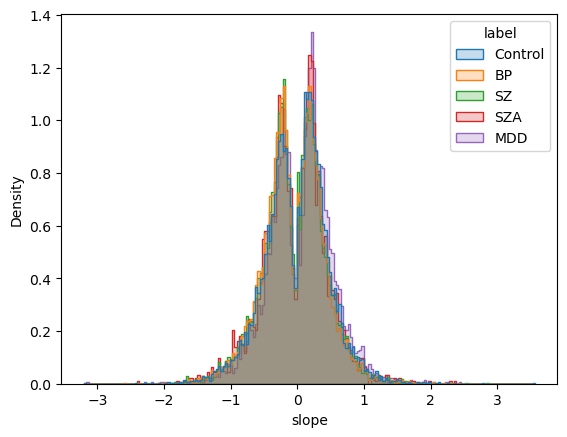

In [30]:
# make label categorical
df_mitoslope['label'] = df_mitoslope['label'].astype('category')
# set order of categories
df_mitoslope['label'] = df_mitoslope['label'].cat.reorder_categories(["Control","BP","SZ","SZA","MDD"], ordered=True)
sns.histplot(data=df_mitoslope, x="slope", hue="label", stat="density", common_norm=False, element="step")

<Axes: xlabel='slope', ylabel='Density'>

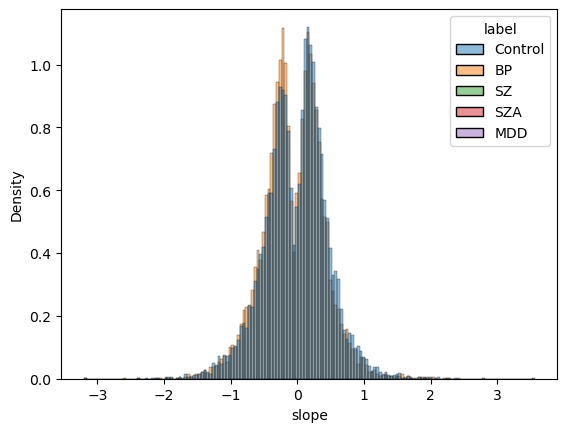

In [31]:
sns.histplot(data=df_mitoslope.loc[df_mitoslope['label'].isin(['Control', 'BP'])], x="slope", hue="label", stat="density", common_norm=False)

<Axes: xlabel='slope', ylabel='Density'>

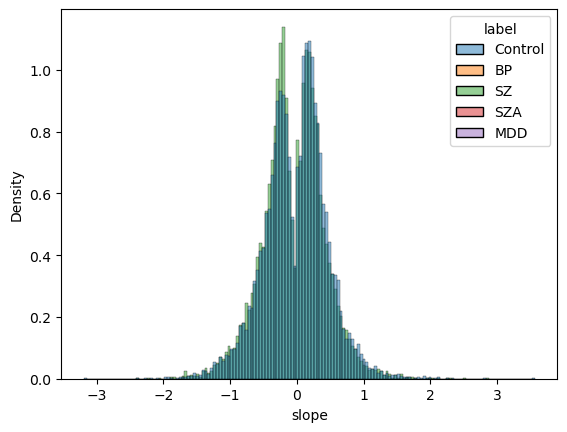

In [32]:
sns.histplot(data=df_mitoslope.loc[df_mitoslope['label'].isin(['Control', 'SZ'])], x="slope", hue="label",stat="density", common_norm=False)

<Axes: xlabel='slope', ylabel='Density'>

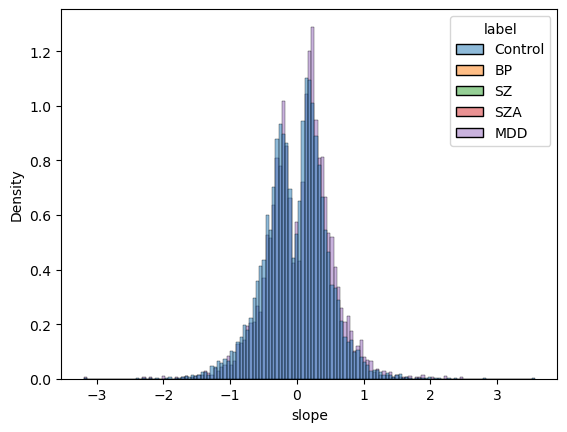

In [33]:
sns.histplot(data=df_mitoslope.loc[df_mitoslope['label'].isin(['Control', 'MDD'])], x="slope", hue="label",stat="density", common_norm=False)

<Axes: xlabel='slope', ylabel='Density'>

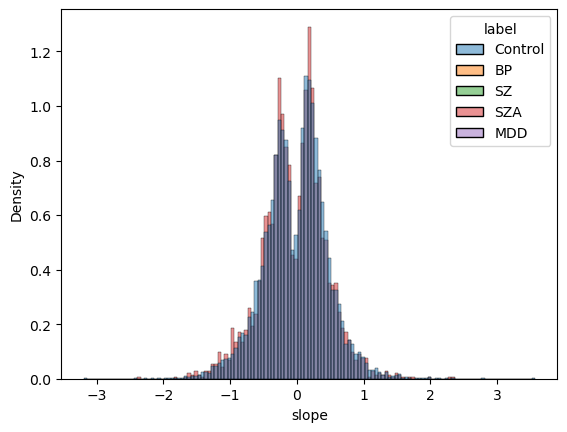

In [34]:
sns.histplot(data=df_mitoslope.loc[df_mitoslope['label'].isin(['Control', 'SZA'])], x="slope", hue="label",stat="density", common_norm=False)

# Cell Size/Shape - NOT Single Cell

In [ ]:
df_1_avg_persub=df_1.groupby(["subject","label"])[[x for x in df_1.columns if x not in non_feat_cols]].mean().reset_index()
df_1_avg_persub.to_csv('per_subject_avg_raw_profiles.csv',index=False)

In [23]:
cellsize = df_1_avg_persub[['Cells_AreaShape_Area','Cells_AreaShape_MajorAxisLength','Cells_AreaShape_MinorAxisLength','Cells_AreaShape_Perimeter']+['subject','label']]
microns_per_pixel = .161

# convert features to microns
cellsize['Area_Microns'] = cellsize['Cells_AreaShape_Area'] * (microns_per_pixel ** 2)
cellsize['MajorAxisLength_Microns'] = cellsize['Cells_AreaShape_MajorAxisLength'] * microns_per_pixel
cellsize['MinorAxisLength_Microns'] = cellsize['Cells_AreaShape_MinorAxisLength'] * microns_per_pixel
cellsize['Perimeter_Microns'] = cellsize['Cells_AreaShape_Perimeter'] * microns_per_pixel

# add category of psychosis
psych = cellsize.loc[cellsize['label'].isin(['SZ','SZA','BP'])]
psych['label'] = 'psychosis'
cellsize = pd.concat([cellsize, psych], ignore_index=True)

/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_66930/428034857.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cellsize['Area_Microns'] = cellsize['Cells_AreaShape_Area'] * (microns_per_pixel ** 2)
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_66930/428034857.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cellsize['MajorAxisLength_Microns'] = cellsize['Cells_AreaShape_MajorAxisLength'] * microns_per_pixel
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_66930/4280

/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_66930/624517092.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=tar, data=cellsize,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_66930/624517092.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels);
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_66930/624517092.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=tar, data=cellsize,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/v

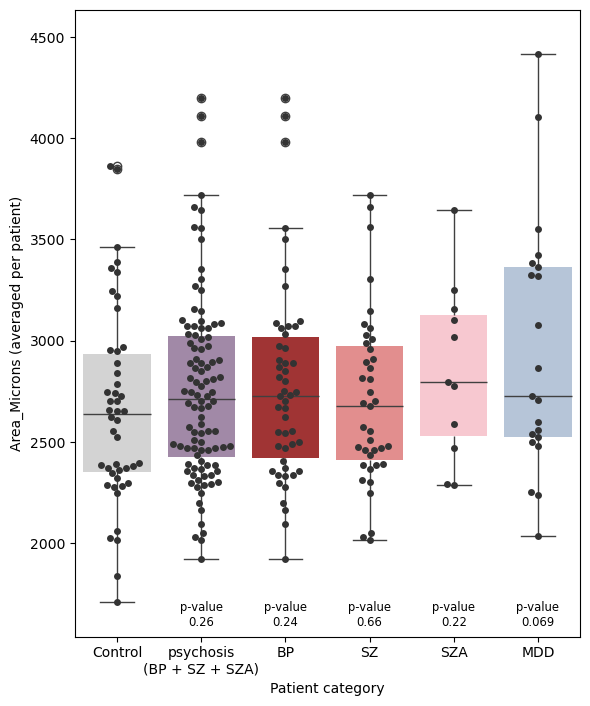

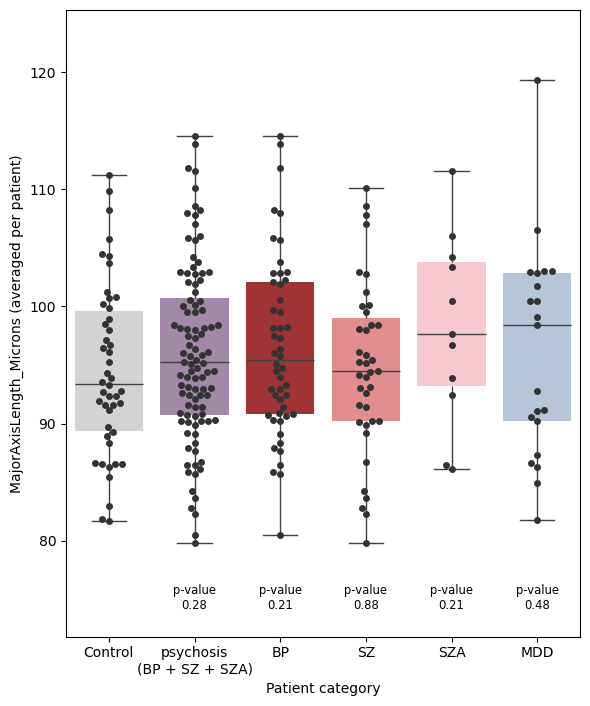

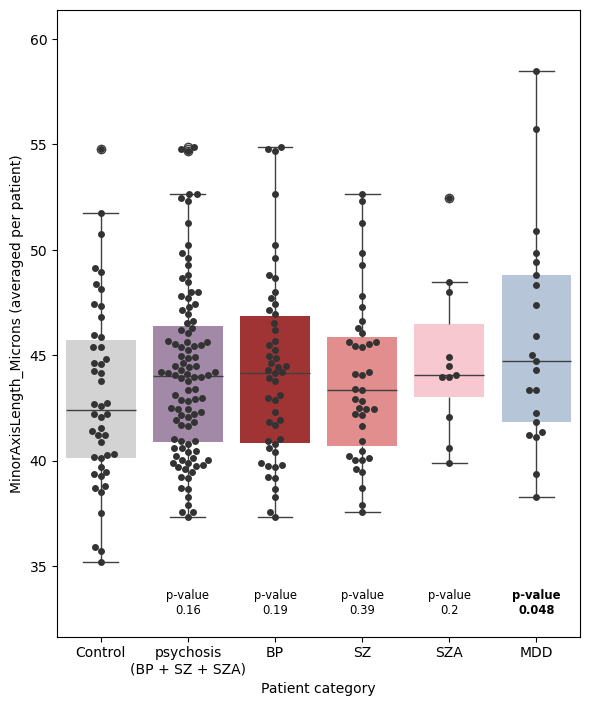

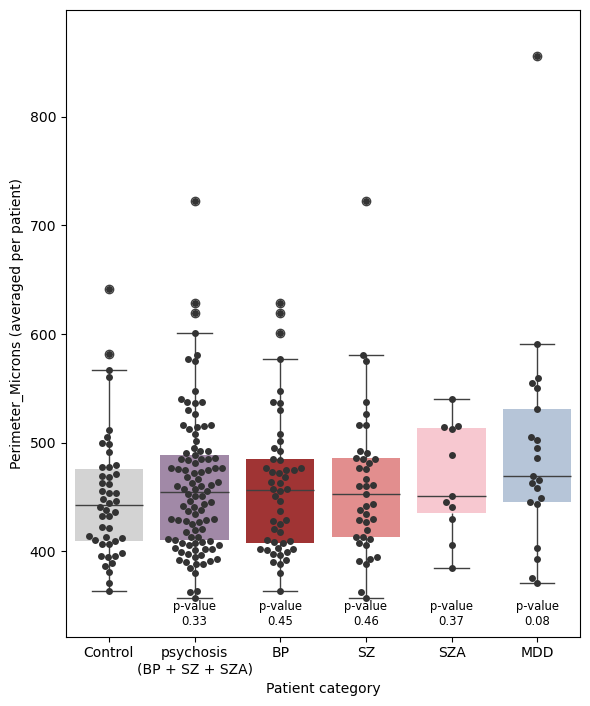

In [30]:
feat_cols = ['Area_Microns','MajorAxisLength_Microns','MinorAxisLength_Microns','Perimeter_Microns']
for tar in feat_cols:
    fig, axes = plt.subplots(1, 1, figsize=(6,7))
    orderC=["Control","psychosis","BP","SZ","SZA","MDD"]
    palette = ['lightgray','#a484ac','firebrick','lightcoral','pink','lightsteelblue']

    sns.boxplot(x="label", y=tar, data=cellsize,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
    sns.swarmplot(x="label", y=tar, data=cellsize,order=orderC,ax=axes, color=".2")
    ############################
    mi,ma=cellsize[tar].describe()[['min','max']]

    for i in range(len(orderC)):
        if orderC[i]!='Control':
            pval=round_sig(ttest_ind(cellsize.loc[cellsize['label']=='Control',tar].values,\
                      cellsize.loc[cellsize['label']==orderC[i],tar].values,equal_var=False).pvalue,2)
            if pval<0.05:
                weight_f='bold';
            else:
                weight_f=None;
            axes.annotate('p-value\n'+str(pval),xy=(i,mi-(.07*mi)),horizontalalignment='center',size='small',weight=weight_f);

    axes.set_ylim([mi-(.1*mi),ma+(.05*ma)]);    

    axes.set(ylabel=tar+' (averaged per patient)');

    axes.set(xlabel='Patient category');
    plt.tight_layout();

    labels = [tick.get_text() for tick in axes.get_xticklabels()];
    labels[1] = "psychosis\n(BP + SZ + SZA)"
    axes.set_xticklabels(labels);

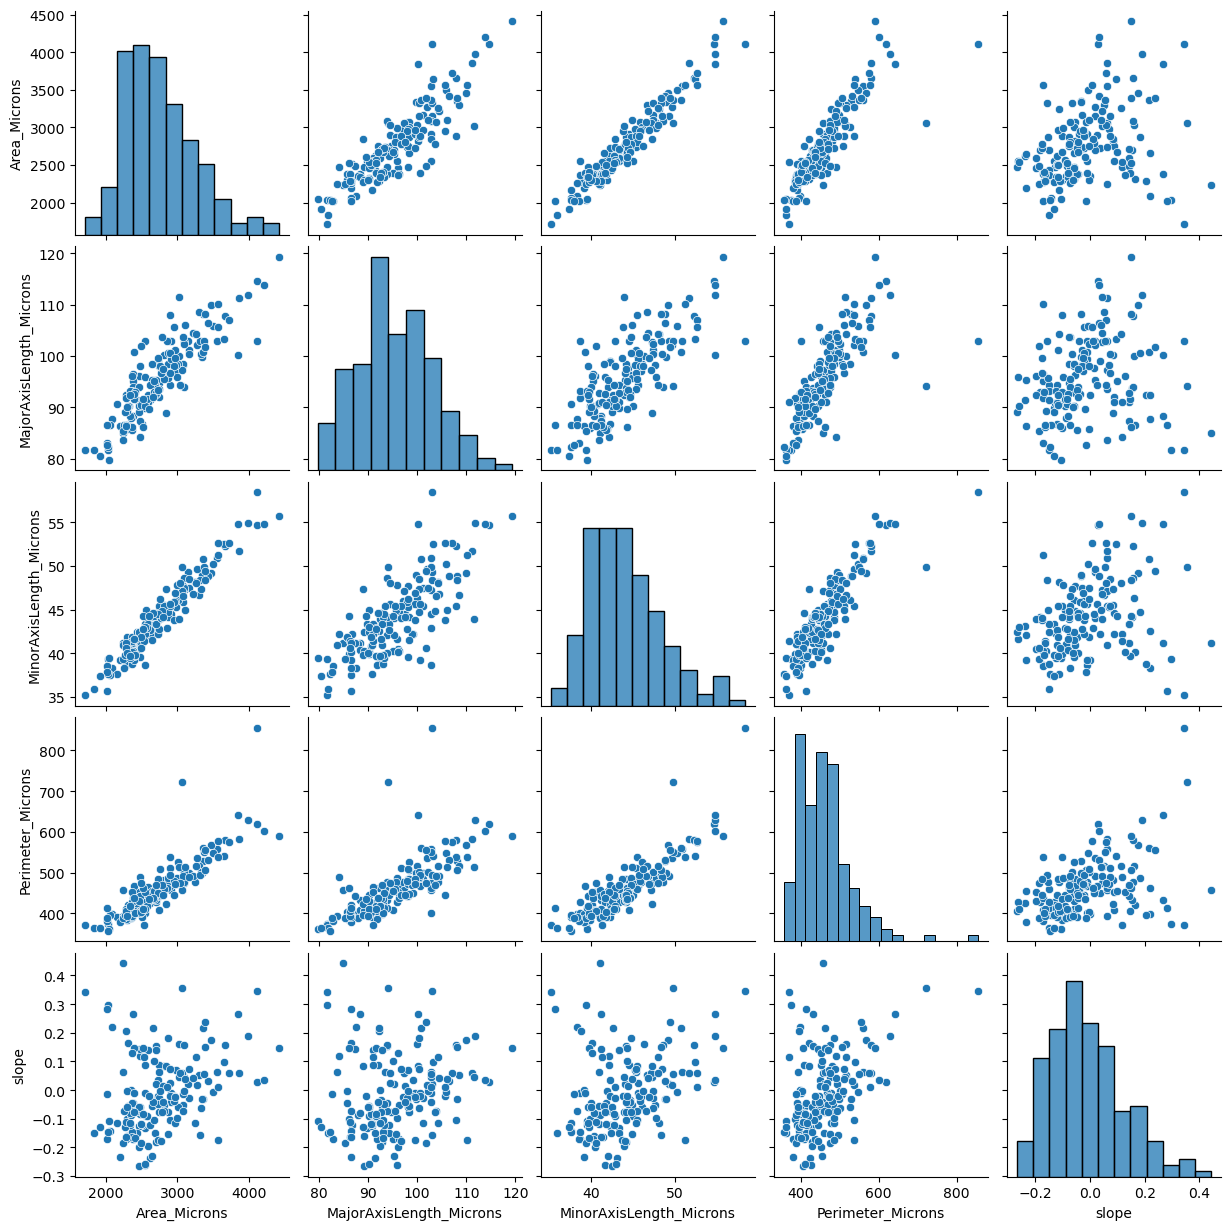

In [31]:
corrplot = cellsize.merge(df_mitoslope.groupby(["subject","label"])[['slope']].mean().reset_index(), on=['subject','label'], how='left')
# drop additional psychosis rows to avoid duplicates in the plot
corrplot = corrplot.loc[corrplot['label']!='psychosis']
sns.pairplot(corrplot[feat_cols+['slope']])
plt.show()